# Problem statement - Identify fraudulent credit card transactions.¶

It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase. Make your machine learning model learn to detect these anomalous transactions

In [2]:
import numpy as np # linear algebra
import pandas as pd 

In [3]:
!pip3 install pycaret

     |████████████████████████████████| 255 kB 190 kB/s eta 0:00:01
     |████████████████████████████████| 60 kB 2.1 MB/s eta 0:00:011
     |████████████████████████████████| 12.4 MB 561 kB/s eta 0:00:01
     |████████████████████████████████| 93 kB 814 kB/s eta 0:00:011
     |████████████████████████████████| 235 kB 8.2 MB/s eta 0:00:01


     |████████████████████████████████| 326 kB 8.1 MB/s eta 0:00:01
     |████████████████████████████████| 49 kB 1.9 MB/s  eta 0:00:01
     |████████████████████████████████| 6.0 MB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 77 kB 4.0 MB/s  eta 0:00:01
     |████████████████████████████████| 2.1 MB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 121 kB 11.5 MB/s eta 0:00:01
     |████████████████████████████████| 84 kB 1.6 MB/s  eta 0:00:01


     |████████████████████████████████| 45 kB 2.2 MB/s  eta 0:00:01
  Created wheel for pyod: filename=pyod-0.8.1-py3-none-any.whl size=105651 sha256=22f2b4beb551d87685e6adb51fe5737d49f284c0e4ac3fe3d0df60c23ffb652b
  Stored in directory: /root/.cache/pip/wheels/d6/f2/24/2c050361bd259bee34bbef8047bbcd3f08085f2a8a5ed1fc85
  Created wheel for querystring-parser: filename=querystring_parser-1.2.4-py3-none-any.whl size=7076 sha256=00f3266651567fedcf0dc85d35e5ccbaba17cbcf48c9c637af274f40419ce8bb
  Stored in directory: /root/.cache/pip/wheels/69/38/7a/072b5863ca334d012821a287fd1d066cea33abdcda3ef2f878
  Created wheel for databricks-cli: filename=databricks_cli-0.11.0-py3-none-any.whl size=90300 sha256=0e95e9439f3b37a7a51afa4e87f6c44e11a880a1bf68ea19258e0e09870fc1c0
  Stored in directory: /root/.cache/pip/wheels/81/3f/18/5678c9d403583e583a251463196998b17852b98de34aa9ab51
  Created wheel for sqlalchemy: filename=SQLAlchemy-1.3.13-cp37-cp37m-linux_x86_64.whl size=1221845 sha256=89f2bddb3d4266bd4

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [5]:
train = pd.read_csv("../input/creditcardfraud/creditcard.csv")

In [5]:
train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# to print the full summary
train.info()

**Setup**

* Setup() performs inferences about the data and creates the transformation pipeline to prepare the data for modeling and deployment.
* Initializing setup() function performs some basic preprocessing tasks like ignoring the IDs and Date Columns, imputing the missing values, encoding the categorical variables, and splitting the dataset into the train-test split, data imbalance, feature selection, binning, etc. for the rest of the modeling steps. When you run the setup function, it will first confirm the data types, and then if you press enter, it will create an environment for data preprocessing.
* It takes 2 mendatory parameter Dataframe and name of the target column

In [6]:
from pycaret.classification import *
classification_setup = setup(data=train,target='Class', normalize=True, session_id=42)

Setup Succesfully Completed!


,Description,Value
0,session_id,42
1,Target Type,Binary
2,Label Encoded,None
3,Original Data,"(284807, 31)"
4,Missing Values,False
5,Numeric Features,30
6,Categorical Features,0
7,Ordinal Features,False
8,High Cardinality Features,False
9,High Cardinality Method,None


So, now the necessary preprocessing is done, let’s create a classification model.

**Compare Models**

* Compare_models function train all the models which are available in library using stratified cross validation, this function will return score grid of all model across k-fold(default=10).
* Scoring matrics used are Accuracy, AUC, Recall, Precision, F1, Kappa and MCC. Mean and standard deviation of the scores across the folds are also returned.
* You can blacklist(omit certain models from the comparison) and whiltelist(un only certain models for the comparison) the model, passig model ID’s as a list of strings eg. whitelist = compare_models(whitelist = ['dt','rf','xgboost']) blacklist = compare_models(blacklist = ['catboost', 'svm'])
* Best model return as per the sort parameter(default=Accuracy) passed.
* Also we can select N top models passing n_select(default=1) parameter

In [10]:
compare_models(sort='Recall')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Quadratic Discriminant Analysis,0.9780,0.9726,0.8866,0.0659,0.1227,0.1199,0.2383,0.3287
1,Naive Bayes,0.9783,0.9639,0.8401,0.0635,0.1181,0.1152,0.2274,0.0872
2,CatBoost Classifier,0.9996,0.9782,0.8140,0.9214,0.8635,0.8633,0.8654,83.7136
3,Extreme Gradient Boosting,0.9995,0.9803,0.7966,0.9238,0.8542,0.8540,0.8570,70.8713
4,Extra Trees Classifier,0.9995,0.9638,0.7934,0.9362,0.8579,0.8577,0.8611,13.9010
5,K Neighbors Classifier,0.9995,0.9198,0.7818,0.9040,0.8374,0.8372,0.8399,0.9547
6,Random Forest Classifier,0.9995,0.9299,0.7675,0.9302,0.8395,0.8393,0.8439,10.8074
7,Linear Discriminant Analysis,0.9994,0.9842,0.7616,0.8782,0.8148,0.8145,0.8171,0.6878
8,Decision Tree Classifier,0.9991,0.8703,0.7412,0.7356,0.7367,0.7362,0.7371,14.0669
9,Ada Boost Classifier,0.9993,0.9753,0.7324,0.8431,0.7813,0.7809,0.7842,46.4818


QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)

**Create Model**

* Let’s create an individual model that displays different evaluation matric using 10 k-fold with mean and std.
* create_model function takes just the one parameter – the model abbreviation as a string.

In [13]:
qda_cls = create_model('qda')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9794,0.9966,0.9714,0.0767,0.1423,0.1395,0.2701
1,0.9773,0.9835,0.8286,0.0609,0.1135,0.1106,0.2211
2,0.9803,0.9687,0.8571,0.0718,0.1325,0.1296,0.2448
3,0.9773,0.9567,0.9143,0.0664,0.1238,0.1209,0.2430
4,0.9756,0.9808,0.8824,0.0585,0.1097,0.1068,0.2236
5,0.9791,0.9894,0.9412,0.0717,0.1333,0.1306,0.2568
6,0.9778,0.9604,0.8235,0.0602,0.1122,0.1094,0.2191
7,0.9776,0.9688,0.9118,0.0654,0.1220,0.1192,0.2409
8,0.9776,0.9348,0.8235,0.0598,0.1116,0.1087,0.2184
9,0.9784,0.9864,0.9118,0.0677,0.1260,0.1232,0.2452


In [14]:
tune_qda = tune_model(qda_cls, optimize = 'Recall', choose_better = True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9794,0.9966,0.9714,0.0767,0.1423,0.1395,0.2701
1,0.9773,0.9835,0.8286,0.0609,0.1135,0.1106,0.2211
2,0.9803,0.9687,0.8571,0.0718,0.1325,0.1296,0.2448
3,0.9773,0.9567,0.9143,0.0664,0.1238,0.1209,0.2430
4,0.9756,0.9808,0.8824,0.0585,0.1097,0.1068,0.2236
5,0.9791,0.9894,0.9412,0.0717,0.1333,0.1306,0.2568
6,0.9778,0.9604,0.8235,0.0602,0.1122,0.1094,0.2191
7,0.9776,0.9688,0.9118,0.0654,0.1220,0.1192,0.2409
8,0.9776,0.9348,0.8235,0.0598,0.1116,0.1087,0.2184
9,0.9784,0.9864,0.9118,0.0677,0.1260,0.1232,0.2452


# **Balancing Imbalance Data**

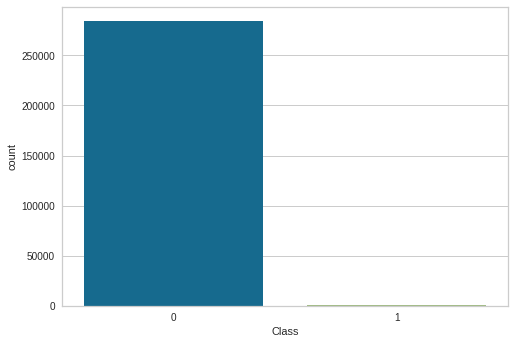

Percent of fraud transaction:  0.1727485630620034 %
Percent of normal transaction:  99.82725143693798 %


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(train['Class'])
plt.show()
print('Percent of fraud transaction: ',len(train[train['Class']==1])/len(train['Class'])*100,"%")
print('Percent of normal transaction: ',len(train[train['Class']==0])/len(train['Class'])*100,"%")

Only 492 (or 0.172%) of transaction are fraudulent. That means the data is highly unbalanced with respect with target variable Class.

Now we are fixing imbalanced dataset using a function **fix_imbalance = True** and **fix_imbalance_method = SMOTE**.

In [7]:
classification_setup1 = setup(data=train,target='Class', normalize=True, session_id=42, fix_imbalance = True)

Setup Succesfully Completed!


,Description,Value
0,session_id,42
1,Target Type,Binary
2,Label Encoded,None
3,Original Data,"(284807, 31)"
4,Missing Values,False
5,Numeric Features,30
6,Categorical Features,0
7,Ordinal Features,False
8,High Cardinality Features,False
9,High Cardinality Method,None


We are excluding gradient boosting classifier using blacklist function, it is taking a lot time to run on a vast dataset 

In [8]:
compare_models(sort='Recall', blacklist = ['gbc'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,SVM - Linear Kernel,0.9764,0.0000,0.9275,0.0650,0.1214,0.1185,0.2416,1.3146
1,Logistic Regression,0.9776,0.9791,0.9187,0.0670,0.1248,0.1220,0.2445,3.0010
2,Ada Boost Classifier,0.9817,0.9719,0.9012,0.0795,0.1460,0.1433,0.2644,130.7691
3,Quadratic Discriminant Analysis,0.9741,0.9658,0.9011,0.0575,0.1080,0.1051,0.2238,0.7241
4,Naive Bayes,0.9765,0.9622,0.8662,0.0605,0.1130,0.1102,0.2252,0.2090
5,K Neighbors Classifier,0.9980,0.9355,0.8603,0.4676,0.6045,0.6036,0.6326,3.3672
6,CatBoost Classifier,0.9988,0.9777,0.8487,0.6153,0.7109,0.7103,0.7208,89.4595
7,Light Gradient Boosting Machine,0.9987,0.9693,0.8429,0.5902,0.6928,0.6922,0.7040,12.4063
8,Ridge Classifier,0.9877,0.0000,0.8397,0.1081,0.1915,0.1890,0.2986,0.3585
9,Linear Discriminant Analysis,0.9877,0.9690,0.8397,0.1081,0.1915,0.1890,0.2986,1.8471


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=42, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

In [9]:
svm_cls = create_model('svm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9810,0.0000,0.9714,0.0827,0.1525,0.1497,0.2806
1,0.9795,0.0000,0.8857,0.0711,0.1316,0.1288,0.2477
2,0.9743,0.0000,0.8857,0.0574,0.1078,0.1049,0.2218
3,0.9732,0.0000,0.9143,0.0567,0.1068,0.1039,0.2241
4,0.9772,0.0000,0.9412,0.0660,0.1233,0.1205,0.2460
5,0.9742,0.0000,0.9706,0.0604,0.1138,0.1109,0.2389
6,0.9765,0.0000,0.9706,0.0659,0.1234,0.1206,0.2497
7,0.9741,0.0000,0.9412,0.0585,0.1102,0.1073,0.2312
8,0.9821,0.0000,0.8529,0.0761,0.1398,0.1371,0.2517
9,0.9725,0.0000,0.9412,0.0553,0.1044,0.1015,0.2245


In [10]:
tune_svm = tune_model(svm_cls, optimize = 'Recall', choose_better = True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.5457,0.0000,0.9714,0.0037,0.0075,0.0040,0.0434
1,0.5416,0.0000,0.9714,0.0037,0.0074,0.0039,0.0430
2,0.5540,0.0000,1.0000,0.0039,0.0078,0.0043,0.0466
3,0.5367,0.0000,0.9714,0.0037,0.0073,0.0038,0.0426
4,0.5477,0.0000,0.9706,0.0036,0.0073,0.0039,0.0429
5,0.5554,0.0000,1.0000,0.0038,0.0076,0.0042,0.0460
6,0.5377,0.0000,1.0000,0.0037,0.0073,0.0039,0.0444
7,0.5613,0.0000,1.0000,0.0039,0.0077,0.0043,0.0466
8,0.5622,0.0000,1.0000,0.0039,0.0077,0.0043,0.0467
9,0.5491,0.0000,1.0000,0.0038,0.0075,0.0041,0.0455


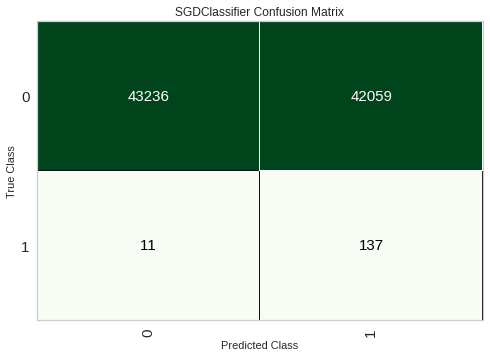

In [12]:
# plotting a model
plot_model(tune_svm,plot = 'confusion_matrix')

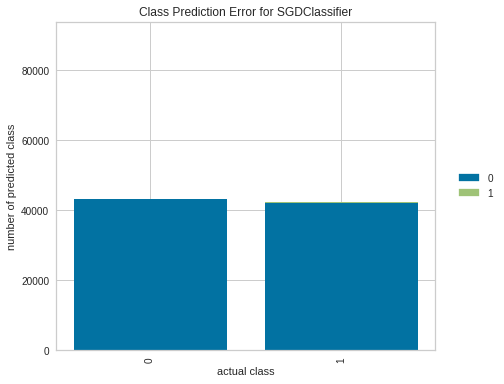

In [13]:
# error Curve
plot_model(tune_svm, plot = 'error')

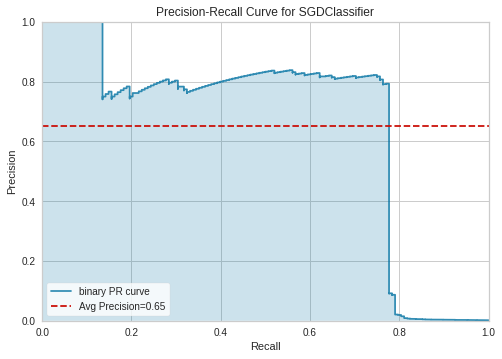

In [15]:
# Precision Recall Curve
plot_model(tune_svm, plot = 'pr')

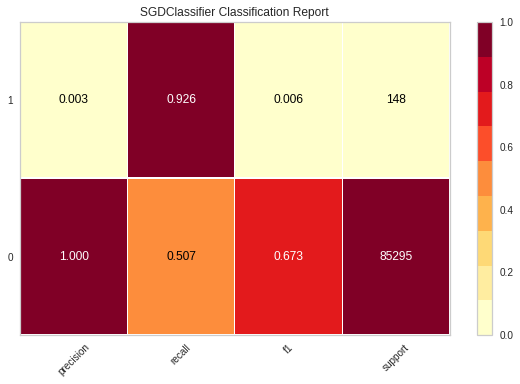

In [17]:
# Classification Report Curve
plot_model(tune_svm, plot = 'class_report')

In [23]:
y_pred = predict_model(tune_svm)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,SVM - Linear Kernel,0.5076,0,0.9257,0.0032,0.0065,0.003,0.036
